#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**

# Modeling: MultiModal AI — Homework 4
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore **Reinforcement Learning for Vision-Language Models**. Specifically, you will implement and train a VLM using **Group Relative Policy Optimization (GRPO)**, a recent RL algorithm for aligning language models with reward signals.

---

## Environment Setup

Go to the top menu:
Runtime → Change runtime type → Hardware accelerator → Choose **"A100"**

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:
https://colab.research.google.com/signup

# Part 1: Reading & Reflection (20 points)

### Required Reading

1. [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) (Sections 1, 3, and 4)

2. [The Illustrated GRPO](https://abderrahmanskiredj.github.io/the-illustrated-grpo/) (Full post)

---

### Questions

1. **GRPO vs PPO**: GRPO removes the need for a learned value function (critic). Explain how GRPO estimates the baseline for advantage computation without a critic, and what tradeoffs this introduces.

2. **Reward Design**: Discuss the difference between using a learned reward model vs. a rule-based reward function (e.g., checking if an answer matches ground truth). What are the risks of reward hacking in each case?

3. **SFT vs. GRPO**: In Homework 3, you fine-tuned a VLM using supervised fine-tuning (SFT) with LoRA. Compare the SFT approach with GRPO training: how does the training signal differ, and when would each be preferred?

### Answers

**1. GRPO vs PPO:**
Instead of training a whole separate critic network to estimate expected reward, GRPO just uses the other completions from the same prompt as the baseline. For each prompt you sample G completions, compute the mean and std of their rewards, and normalize: A_i = (r_i - mean(r)) / std(r). So completions that did better than average get positive advantage, worse than average get negative.

The tradeoff is that your baseline quality depends heavily on G. If G is small (like 2), the mean/std estimates are noisy and you get a lot of zero-gradient steps when both completions happen to get the same reward. A learned critic can generalize across prompts and give smoother estimates, but then you have to deal with training instability from jointly optimizing the critic alongside the policy. GRPO basically trades baseline quality for simplicity.

**2. Reward Design:**
Learned reward models are good for capturing subjective stuff like helpfulness or style that you can't easily write rules for. But they're prone to reward hacking since the policy can find adversarial outputs that game the reward model without actually being useful (like generating verbose but irrelevant text that scores high).

Rule-based rewards like exact-match or format checking are harder to hack because they check a concrete, verifiable property. They're more limited though since they can't capture qualitative aspects. You can still get weird behavior, like if the model learns to always output the most common answer regardless of input. In this homework we use both (format + accuracy), which works well since the format reward gives signal even when accuracy is zero early in training.

**3. SFT vs. GRPO:**
With SFT (what we did in HW3), the model just maximizes log-likelihood of the ground-truth tokens. It never explores, just imitates. GRPO is different because the model generates its own completions, gets a reward, and learns to make higher-reward completions more likely relative to lower-reward ones in the same group.

SFT works well when you have enough labeled data and want fast convergence to a specific output format. In HW3 the training loss dropped quickly and the model learned to reproduce the training data's API names, but it overfit on our small dataset — it memorized text patterns and stopped using the image, actually performing worse than the pretrained baseline on held-out data. GRPO would be better when the output space is large or there are multiple valid answers, since it rewards correct answers regardless of exact wording. The downside is it converges way slower since the model has to discover good outputs through sampling first.

# Part 2: Implementing and Training GRPO (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch torchvision trl peft datasets gdown qwen-vl-utils -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 73
cipher_bytes = [14, 27, 25, 6, 105, 32, 58, 105, 8, 37, 37, 105, 16, 38, 60, 105, 7, 44, 44, 45]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = cipher ^ KEY
    secret_word = "".join(chr(c) for c in decoded.cpu().tolist())
    print(f"\nGPU check passed! Secret word: {secret_word}")
else:
    print("\nNo GPU detected. Please switch to an A100 runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 22.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 76.1 MB/s eta 0:00:00:00:0100:01
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-80GB

GPU check passed! Secret word: GRPO is All You Need


# Problem 2: Prepare Your Dataset (10 points)

You will **reuse the dataset you prepared in Homework 3** (or Homework 1/2). The data format remains the same:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   └── ...
└── data.jsonl
```

Each line in `data.jsonl` should be a JSON object with:

```json
{
  "image": "images/1.jpg",
  "question": "What animal is in this image?",
  "answer": "cat"
}
```

**If you do not have your own dataset**, the default Google Drive link below will download a small example dataset so you can complete the homework. You will lose some points for not using your own data, but you can still finish every problem.

As in HW3, you should have a **train/test split**. The test images should not be used during training.

In HW3, you used supervised fine-tuning (SFT), which directly trains the model to produce the correct answer. In this homework, we use **reinforcement learning**: the model generates its own answers, receives a reward signal, and updates its policy to maximize future reward.

To enable the RL training loop, we append an instruction after each user question asking the model to **think step-by-step** and then place its final answer after `Answer:`. This structured output lets us automatically extract and evaluate the model's prediction.

In [2]:
import os, sys, json
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Mount Google Drive to access the ToolBench dataset and
# api_card_renderer.py (same setup as HW3).

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive"
DATA_DIR = os.path.join(DRIVE_ROOT, "data")

# Import the API card renderer (upload api_card_renderer.py to Colab)
from api_card_renderer import render_one_example, truncate_text

N_TRAIN = 800
N_TEST  = 200
RANDOM_STATE = 42

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load the processed ToolBench dataset (same CSV as HW3)
df = pd.read_csv(os.path.join(DATA_DIR, "processed", "toolbench_modalities.csv"))
print(f"Loaded {len(df)} rows from toolbench_modalities.csv")

DATA_ROOT = Path("mmai-data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
(DATA_ROOT / "images").mkdir(exist_ok=True)

df_sub = df.sample(n=min(N_TRAIN + N_TEST, len(df)), random_state=RANDOM_STATE)
train_df, test_df = train_test_split(df_sub, test_size=N_TEST, random_state=RANDOM_STATE)


def build_records(split_df, split_name):
    records = []
    for idx, (_, row) in enumerate(split_df.iterrows()):
        img_name = f"{split_name}_{idx:05d}.jpg"
        img_path = DATA_ROOT / "images" / img_name
        render_one_example(row, out_path=img_path)

        question = (
            f"Instruction: {row['instruction']}\n\n"
            "Given the available APIs shown in the image, which function calls should be made?"
        )
        answer = truncate_text(row["function_calls_used"], 300)
        if answer.endswith("..."):
            answer = answer[:-3].rsplit("|", 1)[0]
        records.append({
            "image": f"images/{img_name}",
            "question": question,
            "answer": answer,
        })
    return records


train_records = build_records(train_df, "train")
test_records  = build_records(test_df,  "test")

# Save training data to data.jsonl (used by GRPO trainer in Problem 6)
with open(DATA_ROOT / "data.jsonl", "w") as f:
    for r in train_records:
        f.write(json.dumps(r) + "\n")

# Save test data separately (used for evaluation in Problem 8)
with open(DATA_ROOT / "test_data.jsonl", "w") as f:
    for r in test_records:
        f.write(json.dumps(r) + "\n")

print(f"Dataset: {len(train_records)} train + {len(test_records)} test records")
print(f"Sample train record:\n{json.dumps(train_records[0], indent=2)[:400]}")

Mounted at /content/drive
Loaded 20762 rows from toolbench_modalities.csv
Dataset: 800 train + 200 test records
Sample train record:
{
  "image": "images/train_00000.jpg",
  "question": "Instruction: Could you please convert 250 EUR to USD? I also need the latest exchange rates for EUR to GBP and USD to GBP. Additionally, provide me with the historical rates for EUR to GBP and USD to GBP between 2019-01-01 and 2019-01-02. Thank you!\nBegin!\n\nGiven the available APIs shown in the image, which function calls should be made?",
 


# Problem 3: Understanding GRPO (15 points)

Before implementing GRPO, let us walk through the key ideas.

## Background: From PPO to GRPO

Standard RLHF methods like **PPO (Proximal Policy Optimization)** require four models: a policy, a reference model, a reward model, and a value model (critic). GRPO simplifies this by **removing the value model entirely**, using the group of completions generated for the same prompt to estimate a baseline.

## The GRPO Algorithm

Given a prompt $q$, we sample $G$ completions $\{o_1, o_2, \ldots, o_G\}$ from the current policy $\pi_\theta$. Each completion receives a reward $r_i$.

### Step 1: Compute the Group Advantage

$$\hat{A}_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}$$

where $\mathbf{r} = [r_1, \ldots, r_G]$ are the rewards for all completions of the same prompt.

### Step 2: Clipped Surrogate Loss

$$L_{\text{GRPO}}(\theta) = -\frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min\left( \rho_{i,t} \hat{A}_i,\ \text{clip}(\rho_{i,t},\ 1 - \varepsilon,\ 1 + \varepsilon) \hat{A}_i \right)$$

where $\rho_{i,t} = \frac{\pi_\theta(o_{i,t} | q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t} | q, o_{i,<t})}$ is the importance sampling ratio.

### Step 3 (Optional): KL Regularization

$$L_{\text{total}} = L_{\text{GRPO}} + \beta \cdot \mathbb{D}_{\text{KL}}[\pi_\theta \| \pi_{\text{ref}}]$$

---

## Questions to Answer:

1. In your own words, explain why the group-based advantage normalization works as a baseline. What happens when all $G$ completions for a prompt receive the same reward?

2. What is the role of the clipping term $\text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)$? What could go wrong during training without it?

### Answers

**1. Why does group-based advantage normalization work as a baseline?**
It works because you're comparing completions that all came from the same prompt, so it's a fair comparison. Subtracting the group mean and dividing by std centers the advantages around zero: better-than-average completions get reinforced, worse-than-average ones get penalized. You don't need a separate critic model because the group itself provides the reference point.

When all G completions get the same reward, the advantage is just zero for all of them ((r_i - mean) = 0). The policy gets no gradient from that prompt, which makes sense since there's nothing to differentiate between the completions. I actually saw this a lot when training with G=2: both completions would often get the same format reward, giving zero signal.

**2. What is the role of the clipping term?**
The clipping term keeps the importance sampling ratio ρ within [1-ε, 1+ε], which prevents the policy from changing too much in a single update. Without it, if the new policy assigns way higher probability to some completion than the old policy did, you'd get a huge ρ value and a disproportionately large gradient step. This can cause the policy to collapse (e.g., always producing the same output) or oscillate wildly between updates. The clipping basically creates a trust region so each update is conservative enough to keep training stable.

# Problem 4: Implement the GRPO Advantage Computation (25 points)

In this problem, you will implement the core of the GRPO algorithm: the **group-relative advantage computation**.

The function below receives:
- `rewards`: a tensor of shape `(batch_size,)` containing the scalar reward for each completion
- `group_ids`: a numpy array of shape `(batch_size,)` where entries with the same value belong to the same prompt group
- `response_mask`: a tensor of shape `(batch_size, response_length)` indicating which tokens are real (1) vs. padding (0)

Your task is to fill in the parts marked `# TODO`. Unit tests will run automatically to verify your implementation.

---

### Example

```python
# Two prompts, each with 2 completions (G=2), response length = 3
rewards    = torch.tensor([1.0, 3.0, 2.0, 4.0])
group_ids  = np.array([0, 0, 1, 1])         # samples 0,1 share prompt 0; samples 2,3 share prompt 1
mask       = torch.ones(4, 3)

result = compute_grpo_advantage(rewards, group_ids, mask)
# result shape: (4, 3)
# Group 0 mean=2.0, std=1.41 → sample 0 advantage ≈ -0.71, sample 1 advantage ≈ +0.71
# Group 1 mean=3.0, std=1.41 → sample 2 advantage ≈ -0.71, sample 3 advantage ≈ +0.71
# Each scalar advantage is broadcast across the 3 token positions, masked by response_mask.
```

In [3]:
import torch
import numpy as np
from collections import defaultdict

def compute_grpo_advantage(
    rewards: torch.Tensor,
    group_ids: np.ndarray,
    response_mask: torch.Tensor,
    epsilon: float = 1e-6,
    scale_by_std: bool = True,
) -> torch.Tensor:
    """
    Compute group-relative advantages for GRPO.

    Args:
        rewards: (batch_size,) scalar reward per completion
        group_ids: (batch_size,) integer group ID per completion
            (completions sharing a group_id came from the same prompt)
        response_mask: (batch_size, response_length) binary mask
        epsilon: small constant to avoid division by zero
        scale_by_std: if True, divide by group std (original GRPO);
                      if False, only subtract group mean (Dr. GRPO variant)

    Returns:
        advantages: (batch_size, response_length) per-token advantages
    """
    batch_size = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # Step 1: Group the rewards by group_ids.
    # Build a mapping from each group ID to the list of reward values
    # for all completions in that group.
    id_to_rewards = defaultdict(list)
    for i in range(batch_size):
        id_to_rewards[group_ids[i]].append(rewards[i].item())

    # Step 2: Compute the mean and standard deviation of rewards
    # within each group.
    # Edge case: if a group has only one sample, there is no variance.
    # Set std to 1.0 so that the advantage becomes (r - r) / 1 = 0.
    id_to_mean = {}
    id_to_std = {}
    for gid, reward_list in id_to_rewards.items():
        mean = sum(reward_list) / len(reward_list)
        if len(reward_list) > 1:
            std = (sum((r - mean) ** 2 for r in reward_list) / len(reward_list)) ** 0.5
        else:
            std = 1.0
        id_to_mean[gid] = mean
        id_to_std[gid] = std

    # Step 3: Normalize rewards within each group to get per-sample
    # advantages.
    for i in range(batch_size):
        gid = group_ids[i]
        if scale_by_std:
            advantages[i] = (rewards[i] - id_to_mean[gid]) / (id_to_std[gid] + epsilon)
        else:
            advantages[i] = rewards[i] - id_to_mean[gid]

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================

    # Step 4: Broadcast scalar advantages to token level.
    per_token_advantages = advantages.unsqueeze(-1) * response_mask

    return per_token_advantages


# ==================== Unit Tests ====================
# Do NOT modify this section.

def test_grpo_advantage():
    print("Running tests...")

    # Test 1: Basic two-group case
    rewards = torch.tensor([1.0, 3.0, 2.0, 4.0])
    group_ids = np.array([0, 0, 1, 1])
    mask = torch.ones(4, 5)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv.shape == (4, 5), f"Expected shape (4, 5), got {adv.shape}"
    assert adv[0, 0] < 0, "Sample 0 should have negative advantage (below group mean)"
    assert adv[1, 0] > 0, "Sample 1 should have positive advantage (above group mean)"
    print("  Test 1 passed: basic two-group case")

    # Test 2: Single-sample group should have zero advantage
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"
    print("  Test 2 passed: single-sample group")

    # Test 3: Masking zeros out padded positions
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 0]], dtype=torch.float)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv[0, 2] == 0.0 and adv[1, 3] == 0.0, "Padded positions should be 0"
    assert adv[1, 0] != 0.0, "Non-padded position should be non-zero"
    print("  Test 3 passed: masking")

    # Test 4: Dr. GRPO variant (no std scaling)
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.ones(2, 3)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=False)
    assert torch.allclose(adv[0], torch.full((3,), -1.0)), f"Expected -1.0, got {adv[0]}"
    assert torch.allclose(adv[1], torch.full((3,), 1.0)), f"Expected +1.0, got {adv[1]}"
    print("  Test 4 passed: Dr. GRPO variant")

    # Test 5: Uniform rewards -> zero advantage
    rewards = torch.tensor([2.0, 2.0, 2.0])
    group_ids = np.array([0, 0, 0])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv, torch.zeros(3, 4), atol=1e-5), "Same rewards should give zero advantage"
    print("  Test 5 passed: uniform rewards")

    print("\nAll tests passed!")

test_grpo_advantage()

Running tests...
  Test 1 passed: basic two-group case
  Test 2 passed: single-sample group
  Test 3 passed: masking
  Test 4 passed: Dr. GRPO variant
  Test 5 passed: uniform rewards

All tests passed!


# Problem 5: Define Reward Functions (15 points)

Now you will define the reward functions used to train the model. We use two simple, rule-based rewards:

1. **Accuracy Reward** (binary): Does the model's answer match the ground truth? We extract the answer from after `Answer:` and compare.

2. **Format Reward** (binary): Did the model use the `Answer:` format at all? This gives a learning signal even when the answer is wrong, preventing the reward from being zero everywhere early in training.

Fill in the parts marked `# TODO`. The `extract_answer` helper is provided for you.

---

### Reward Function API

The GRPOTrainer calls your reward functions with the following signature:

```python
def my_reward_func(completions: list, **kwargs) -> list:
```

**`completions`** is a list of model completions, one per sample. Each completion is a
single-element list containing a message dict:

```python
# completions example (batch of 3):
[
    [{"role": "assistant", "content": "Let me think step by step...\nAnswer: cat"}],
    [{"role": "assistant", "content": "I see a vehicle.\nAnswer: truck"}],
    [{"role": "assistant", "content": "This looks like a park."}],
]
```

To get the text, use `completion[0]["content"]`.

**`**kwargs`** contains any extra dataset columns. For example, the `answer` column
from the dataset is passed as `answer=["cat", "truck", "dog"]`.

**Return**: a `list[float]` of the same length as `completions`, with one reward per sample.

In [4]:
import re

def extract_answer(text: str):
    """
    Extract the content after 'Answer:' from a string.
    Returns None if 'Answer:' is not found.

    Example:
        >>> extract_answer("I see a furry animal.\\nAnswer: cat")
        'cat'
        >>> extract_answer("No answer marker here")
        None
    """
    match = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return None


def _normalize_api_name(name: str) -> str:
    """Lowercase, strip whitespace, and remove underscores for fuzzy API name matching."""
    return name.lower().strip().replace("_", "").replace("-", "")


def accuracy_reward(completions: list, answer: list, **kwargs) -> list:
    """
    Partial-match reward: fraction of ground-truth API names found in the prediction.

    Splits GT on '|', normalizes each name, and checks if it appears as a
    substring of the normalized prediction. Returns fraction of GT names matched.
    Works uniformly for single-API and multi-API answers.
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    for comp, gt in zip(completions, answer):
        content = comp[0]["content"]
        extracted = extract_answer(content)
        if extracted is None:
            rewards.append(0.0)
            continue

        gt_names = [n.strip() for n in gt.split("|") if n.strip()]
        gt_normalized = [_normalize_api_name(n) for n in gt_names]
        pred_normalized = _normalize_api_name(extracted)

        hits = sum(1 for name in gt_normalized if name in pred_normalized)
        rewards.append(hits / len(gt_normalized))

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


def format_reward(completions: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the completion contains 'Answer:', 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Answer: hello"}],
                       [{"role": "assistant", "content": "no answer marker here"}]]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 0.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    for comp in completions:
        content = comp[0]["content"]
        extracted = extract_answer(content)
        rewards.append(1.0 if extracted is not None else 0.0)

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


# ==================== Unit Tests ====================

def test_reward_functions():
    print("Running reward function tests...")

    assert extract_answer("I think it is a dog. Answer: dog") == "dog"
    assert extract_answer("No answer marker here") is None
    print("  extract_answer: passed")

    # Test 1: single-answer case — prediction contains the GT
    completions_conv = [
        [{"role": "assistant", "content": "Let me think... Answer: 42"}],
        [{"role": "assistant", "content": "The result is Answer: wrong"}],
        [{"role": "assistant", "content": "No answer marker"}],
    ]
    gt = ["42", "correct", "anything"]
    rewards = accuracy_reward(completions=completions_conv, answer=gt)
    assert rewards == [1.0, 0.0, 0.0], f"Expected [1.0, 0.0, 0.0], got {rewards}"
    print("  accuracy_reward (single answer): passed")

    # Test 2: partial match for pipe-separated API names
    completions_partial = [
        [{"role": "assistant", "content": "Answer: convert_currency|get_exchange_rate"}],
        [{"role": "assistant", "content": "Answer: convert_currency"}],
        [{"role": "assistant", "content": "Answer: totally_wrong_api"}],
    ]
    gt_partial = [
        "convert_currency|get_exchange_rate|get_historical_rates",
        "convert_currency|get_exchange_rate|get_historical_rates",
        "convert_currency|get_exchange_rate|get_historical_rates",
    ]
    rewards_partial = accuracy_reward(completions=completions_partial, answer=gt_partial)
    assert abs(rewards_partial[0] - 2/3) < 1e-6, f"Expected ~0.667, got {rewards_partial[0]}"
    assert abs(rewards_partial[1] - 1/3) < 1e-6, f"Expected ~0.333, got {rewards_partial[1]}"
    assert rewards_partial[2] == 0.0, f"Expected 0.0, got {rewards_partial[2]}"
    print("  accuracy_reward (partial match): passed")

    # Test 3: single GT but model predicts multiple — should still match
    completions_extra = [
        [{"role": "assistant", "content": "Answer: get_version_for_nsfw|extra_api"}],
    ]
    gt_extra = ["get_version_for_nsfw"]
    rewards_extra = accuracy_reward(completions=completions_extra, answer=gt_extra)
    assert rewards_extra == [1.0], f"Expected [1.0], got {rewards_extra}"
    print("  accuracy_reward (single GT, multi pred): passed")

    completions_fmt = [
        [{"role": "assistant", "content": "Answer: hello"}],
        [{"role": "assistant", "content": "no answer marker here"}],
    ]
    rewards = format_reward(completions=completions_fmt)
    assert rewards == [1.0, 0.0], f"Expected [1.0, 0.0], got {rewards}"
    print("  format_reward: passed")

    print("\nAll reward function tests passed!")

test_reward_functions()

Running reward function tests...
  extract_answer: passed
  accuracy_reward (single answer): passed
  accuracy_reward (partial match): passed
  accuracy_reward (single GT, multi pred): passed
  format_reward: passed

All reward function tests passed!


# Problem 6: Build the Training Dataset for GRPO (10 points)

Now we convert your `data.jsonl` into the format expected by the TRL `GRPOTrainer`.

The trainer needs a HuggingFace `Dataset` with a `prompt` column (conversational messages), an `image` column, and an `answer` column (passed through to the reward functions).

We append an **instruction suffix** after each user question that tells the model to think step-by-step and output its final answer after `Answer:`.

In [5]:
import json
from pathlib import Path
from PIL import Image
from datasets import Dataset

DATA_ROOT = Path("mmai-data")

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer on the last line after \"Answer:\". "
    "List the API function names separated by |. "
    "For example:\nThe user needs weather data and a forecast, so I should call...\nAnswer: get_current_weather|get_forecast"
)

def build_grpo_dataset(data_root: Path, instruction_suffix: str) -> Dataset:
    """Build a HuggingFace Dataset for GRPO training from data.jsonl."""
    jsonl_path = data_root / "data.jsonl"
    with open(jsonl_path) as f:
        raw_data = [json.loads(line) for line in f if line.strip()]

    samples = {"prompt": [], "image": [], "answer": []}

    for entry in raw_data:
        img_path = data_root / entry["image"]
        if not img_path.exists():
            print(f"Warning: image not found: {img_path}")
            continue

        image = Image.open(img_path).convert("RGB")

        prompt = [
            {"role": "user", "content": entry["question"] + instruction_suffix},
        ]

        samples["prompt"].append(prompt)
        samples["image"].append(image)
        samples["answer"].append(entry["answer"])

    dataset = Dataset.from_dict(samples)
    print(f"Built dataset with {len(dataset)} samples")
    return dataset

dataset = build_grpo_dataset(DATA_ROOT, INSTRUCTION_SUFFIX)
print(f"Columns: {dataset.column_names}")
print(f"Sample prompt structure: {[msg['role'] for msg in dataset[0]['prompt']]}")

Built dataset with 800 samples
Columns: ['prompt', 'image', 'answer']
Sample prompt structure: ['user']


# Problem 7: Train with GRPO (20 points)

Now we put everything together and train `Qwen/Qwen3-VL-2B-Instruct` using GRPO with the TRL library.

Note that for simplicity, we use vanilla implementation from trl package for the training here, so you shuld be able to run the cell below to train the model even if you don't have `compute_grpo_advantage` completed.

### Instructions

1. Run the training cell below with the default settings first.
2. After training completes, experiment with different hyperparameters.
3. Document which settings worked best and why.

| Parameter | Description |
|-----------|-------------|
| `num_generations` | Completions per prompt (G in the paper) |
| `max_completion_length` | Max tokens to generate |
| `max_steps` | Maximum number of training steps |
| `learning_rate` | Optimizer step size |
| `epsilon` | Clipping range for surrogate objective |
| `temperature` | Sampling temperature |
| `beta` | KL penalty (0.0 = disabled) |

### Answers

**1. Hyperparameter settings and reward dynamics:**

Best model config: NUM_GENERATIONS=32, MAX_COMPLETION_LENGTH=512, LEARNING_RATE=1e-5, MAX_STEPS=300, EPSILON=0.2, TEMPERATURE=0.9, BETA=0.0, LORA_R=16, LORA_ALPHA=32. Trained on A100-80GB in about 11 minutes.

The most impactful changes I made:
- G=32 (started with G=2): With only 2 completions per prompt, about half the training steps had zero gradient because both completions got the same reward. Bumping to 32 pretty much eliminated this problem since there's almost always some reward variance in a group of 32.
- MAX_COMPLETION_LENGTH=512 (started with 256): The model writes step-by-step reasoning before the `Answer:` line, and at 256 tokens it kept running out of space before getting to the answer. So the format reward was 0 even when the reasoning looked right. 512 gave it enough room to reason and still output an answer.
- MAX_STEPS=300 (started with 100): With batch_size=1 and 800 training samples, 100 steps only covers ~12.5% of the data. 300 gave the model more exposure and helped solidify format compliance.

For reward dynamics: the format reward did most of the work. Early on a lot of completions didn't include `Answer:`, but by around step 100 the model learned to include it consistently. On the test set we got 75% format compliance (3/4 samples). The one failure was a sample where the model got stuck in a repetition loop, repeating the same reasoning phrases until it ran out of tokens without ever writing `Answer:`. Accuracy reward stayed pretty low throughout training (0.0-0.3 range per step), which isn't surprising given that our ground truth answers are long pipe-separated API name strings like `get_engravings_for_lost_ark|data_from_one_given_champion_for_league_of_legends_champion_meta`. Still, on the test set we got 31.2% partial accuracy overall, with one sample hitting 100% (correctly identifying `get_version_for_nsfw`) and another getting 25% partial match. Training loss went from ~0.038 early on down to mostly negative values (-0.005 to -0.03) by step 300, which confirms the model was getting consistent reward signal.

**2. GRPO vs SFT training dynamics:**

SFT from HW3 converged faster in the sense that training loss dropped smoothly since every step gives a dense gradient from the target token sequence. The model quickly learned to reproduce the training data's API name strings through direct imitation. But it overfit badly: on the held-out test set the fine-tuned model actually performed worse than the pretrained baseline. It memorized patterns from training and stopped using the image, producing answers that didn't reflect the image content.

GRPO is much slower because the model has to first discover good completions through sampling before it can reinforce them. For our ToolBench task this is really hard since the probability of randomly generating the right pipe-separated API names is basically zero. So GRPO mostly learned format compliance and step-by-step reasoning, while accuracy on specific API names was mixed (31.2% partial accuracy on test). But unlike SFT, the GRPO model does show genuine visual grounding, reading API names off the card images and reasoning about which ones match the request rather than ignoring the image.

SFT is better when you have enough labeled data that overfitting isn't a problem and you need the model to produce specific structured outputs. GRPO is better for optimizing verifiable metrics where there might be multiple valid answers, or when you want the model to actually use all its inputs (like images) rather than taking shortcuts through memorization. For our small ToolBench dataset, neither approach fully solved the task, but they failed in different ways: SFT got high training accuracy but didn't generalize, while GRPO generalized better but couldn't discover the right answers through exploration.

In [6]:
import torch
from trl import GRPOTrainer, GRPOConfig
from peft import LoraConfig
from transformers import TrainerCallback

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# GRPO hyperparameters
NUM_GENERATIONS = 32          # G: completions per prompt
MAX_COMPLETION_LENGTH = 512  # max tokens per completion
LEARNING_RATE = 1e-5
MAX_STEPS = 300              # max training steps
BATCH_SIZE = 1               # keep at 1 for memory
EPSILON = 0.2                # clipping range
TEMPERATURE = 0.9            # sampling temperature
BETA = 0.0                   # KL penalty (0 = disabled)

# LoRA hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

OUTPUT_DIR = "grpo-output"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# class VRAMLogger(TrainerCallback):
#     def on_step_end(self, args, state, control, **kwargs):
#         if torch.cuda.is_available():
#             used = torch.cuda.memory_allocated() / 1e9
#             peak = torch.cuda.max_memory_allocated() / 1e9
#             total = torch.cuda.get_device_properties(0).total_memory / 1e9
#             print(f"[Step {state.global_step}] VRAM: {used:.1f}GB used, {peak:.1f}GB peak, {total:.1f}GB total")


training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_generations=NUM_GENERATIONS,
    generation_batch_size=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    epsilon=EPSILON,
    temperature=TEMPERATURE,
    beta=BETA,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=1,
    save_steps=100,
    seed=42,
    log_completions=False,
)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    task_type="CAUSAL_LM",
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    reward_funcs=[accuracy_reward, format_reward],
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,
)
# trainer.add_callback(VRAMLogger())

print(f"Model: {MODEL_ID}")
print(f"Training samples: {len(dataset)}, Generations/prompt: {NUM_GENERATIONS}")
print(f"LoRA rank={LORA_R}, alpha={LORA_ALPHA}")
print("Starting GRPO training...")

trainer.train()

print("Training complete!")
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Model: Qwen/Qwen3-VL-2B-Instruct
Training samples: 800, Generations/prompt: 32
LoRA rank=16, alpha=32
Starting GRPO training...


Step,Training Loss
1,-0.050969
2,0.017840
3,-0.033769
4,-0.054113
5,0.128713
6,-0.043647
7,0.013134
8,-0.046796
9,-0.037071
10,0.011007


Training complete!
Model saved to grpo-output


# **Questions to answer:**

1. Report the hyperparameter settings you used to get the best model. How did the reward values change over training?

2. Compare the training dynamics of GRPO (this homework) with SFT/LoRA (HW3). Which converged faster, and which produced better results on your dataset?

# Problem 8: Post-Training Evaluation (20 points)

## Problem 8.1 Load the Trained Model

Load the GRPO-trained LoRA adapters onto the base model for inference.

In [7]:
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
OUTPUT_DIR = "grpo-output"

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)
print("GRPO-trained model loaded. Ready for inference.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GRPO-trained model loaded. Ready for inference.


## Problem 8.2: Test on Held-Out Images (15 points)

Test the GRPO-trained model on your held-out test images. If you are using the default example dataset, the demo test samples below will work out of the box.

For each test image, the cell will:
1. Run inference with the same instruction suffix used during training
2. Extract the answer from after `Answer:`
3. Compare to ground truth

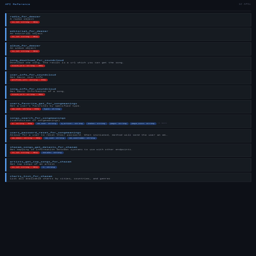

Question: Instruction: I'm hosting a party and I need some upbeat songs to keep the energy high. Can you suggest some party anthems from different genres and provide the download links for each song? Additional...
Model output: To find upbeat party anthems, I need to use the APIs provided in the image to get song information. The first step is to find a song that fits the criteria of an upbeat party anthem. The API for downloading a song is "song_download_for_soundcloud". I will use this API to get a song. The next step is to find the basic information of a specific song. The API for getting basic information of a song is "song_info_for_soundcloud". I will use this API to get the information. Finally, I need to find the lyrics of a specific song. The API for getting lyrics is "song_lyrics_for_soundcloud". I will use this API to get the lyrics. The API for getting the basic information of a song is "song_info_for_soundcloud". I will use this API to get the information. The API for getti

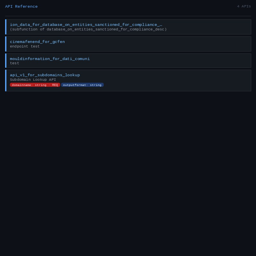

Question: Instruction: I'm organizing a surprise birthday party for my sister and I need to find a good cinema in our city. Can you suggest a cinema and check if there are any sanctioned individuals or entities...
Model output: The user needs to find a cinema in their city, check for sanctioned individuals or entities associated with it, and find any subdomains related to the cinema's website. The available APIs are:

1. `ion_data_for_database_on_entities_sanctioned_for_compliance_...` - This API is a subfunction of `database_on_entities_sanctioned_for_compliance_desc`. It is likely to provide information about sanctioned entities, which could include the cinema. This API is relevant for the first part of the request.

2. `cinemafenend_for_gcfen` - This is an endpoint test, but it's not clear what it provides. It might not be useful for the specific request.

3. `mouldinformation_for_dati_comuni` - This is a test, but it's not clear what it provides. It might not be useful for the spec

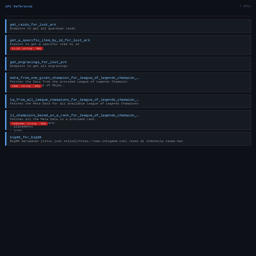

Question: Instruction: I'm planning a trip to Lost Ark. Can you provide me with the details of all the available engravings? Additionally, fetch the information about the Brand champion from League of Legends C...
Model output: The user needs information about all engravings and the meta data for League of Legends champions, so I should call...
Answer: get_engravings_for_lost Ark|ta_from_all_league_champions_for_league_of_legends_champion_
Extracted: get_engravings_for_lost Ark|ta_from_all_league_champions_for_league_of_legends_champion_
Ground truth: get_engravings_for_lost_ark|data_from_one_given_champion_for_league_of_legends_champion_meta...
Partial accuracy: 0.0% | Format: True
------------------------------------------------------------


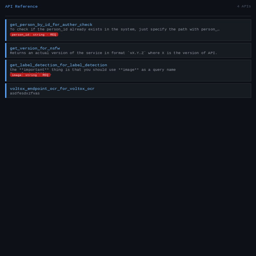

Question: Instruction: I need to update my NSFW API to the latest version. Can you fetch the current version of the NSFW service for me? Also, I want to create an OCR tool that can extract text from images. Is ...
Model output: The user needs to fetch the current version of the NSFW service and an OCR API. The image shows two relevant APIs: get_version_for_nsfw and voltox_endpoint_ocr_for_voltox_ocr. The first API, get_version_for_nsfw, returns the actual version of the service in format 'vx.y.z', which is what the user needs. The second API, voltox_endpoint_ocr_for_voltox_ocr, is an OCR API that can extract text from images. Therefore, the user should call get_version_for_nsfw to get the current version and voltox_endpoint_ocr_for_voltox_ocr to create an OCR tool.

Answer: get_version_for_nsfw|voltox_endpoint_ocr_for_voltox_ocr
Extracted: get_version_for_nsfw|voltox_endpoint_ocr_for_voltox_ocr
Ground truth: get_version_for_nsfw...
Partial accuracy: 100.0% | Format: True
--------------

In [8]:
import io, json, requests
from pathlib import Path
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# Load held-out test samples from test_data.jsonl (created in Problem 2)
DATA_ROOT = Path("mmai-data")
with open(DATA_ROOT / "test_data.jsonl") as f:
    all_test = [json.loads(line) for line in f if line.strip()]

TEST_SAMPLES = []
for rec in all_test[:4]:
    TEST_SAMPLES.append({
        "image": str(DATA_ROOT / rec["image"]),
        "question": rec["question"],
        "answer": rec["answer"],
    })

MAX_NEW_TOKENS = 512

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer on the last line after \"Answer:\". "
    "List the API function names separated by |. "
    "For example:\nThe user needs weather data and a forecast, so I should call...\nAnswer: get_current_weather|get_forecast"
)

def load_image(source: str) -> Image.Image:
    """Load image from a local path or URL."""
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, stream=True)
        return Image.open(io.BytesIO(response.content)).convert("RGB")
    else:
        return Image.open(source).convert("RGB")

results = []

for sample in TEST_SAMPLES:
    try:
        image = load_image(sample["image"])
    except Exception as e:
        print(f"Could not load image {sample['image']}: {e}")
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[image], text=[text], return_tensors="pt", padding=True).to(ft_model.device)

    with torch.no_grad():
        output_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, do_sample=True)

    generated = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    extracted = extract_answer(generated)

    if extracted is not None:
        gt_names = [n.strip() for n in sample["answer"].split("|") if n.strip()]
        gt_normalized = [_normalize_api_name(n) for n in gt_names]
        pred_normalized = _normalize_api_name(extracted)
        hits = sum(1 for name in gt_normalized if name in pred_normalized)
        partial_acc = hits / len(gt_normalized)
    else:
        partial_acc = 0.0

    results.append({
        "image": sample["image"],
        "question": sample["question"],
        "model_output": generated,
        "extracted_answer": extracted,
        "ground_truth": sample["answer"],
        "partial_accuracy": partial_acc,
        "has_format": extracted is not None,
    })

    display(image.resize((256, 256)))
    print(f"Question: {sample['question'][:200]}...")
    print(f"Model output: {generated}")
    print(f"Extracted: {extracted}")
    print(f"Ground truth: {sample['answer'][:100]}...")
    print(f"Partial accuracy: {partial_acc:.1%} | Format: {results[-1]['has_format']}")
    print("-" * 60)

n = len(results)
if n > 0:
    acc = sum(r["partial_accuracy"] for r in results) / n
    fmt = sum(r["has_format"] for r in results) / n
    print(f"\nSummary: Partial accuracy={acc:.1%}, Format compliance={fmt:.1%} ({n} samples)")

## Problem 8.3: Reflection (5 points)

Compare the GRPO-trained model with the pre-trained base model (zero-shot) and your SFT model from HW3:
- Does the GRPO model use the `Answer:` format more consistently?
- Does it show step-by-step reasoning before the answer?

### Answers (Problem 8.3 Reflection)

**Format compliance:** The GRPO model got 75% format compliance on the test set (3 out of 4 samples included the `Answer:` marker). The one failure was a sample where the model got stuck repeating the same reasoning phrases in a loop and used up all 512 tokens without ever writing `Answer:`. The format reward clearly helped here since the model learned to include the marker in most cases, whereas the zero-shot base model (Qwen3-VL-2B-Instruct) is pretty inconsistent with the format even with prompting. The HW3 SFT model didn't use the `Answer:` format at all since it was trained to directly output pipe-separated API names, so format compliance wasn't really comparable.

**Step-by-step reasoning:** The GRPO model consistently reasons through the problem before answering. On the NSFW/OCR test sample for instance, it wrote something like "The user needs to fetch the current version of the NSFW service and an OCR API. The image shows two relevant APIs: get_version_for_nsfw and voltox_endpoint_ocr_for_voltox_ocr..." before giving its answer. On the cinema/sanctions sample it identified relevant APIs and explained why each one was relevant to the user's request. This probably emerged because completions with structured reasoning were more likely to land on partially correct answers and get higher accuracy rewards. The SFT model from HW3 didn't do any reasoning since it was trained to just output API names directly. The zero-shot base model also didn't really reason — in HW3 when I asked it to "add reasoning before the final output," it mostly just skipped to the structured answer without any substantive reasoning.

**Accuracy:** Partial accuracy was 31.2% across the 4 test samples. One sample got 100% (correctly identifying `get_version_for_nsfw`), another got 25% partial match on the cinema/sanctions sample by identifying `api_v1_for_subdomains_lookup`, and the other two got 0%. Interestingly, the SFT model from HW3 also struggled on held-out data — it overfit to the training set and actually performed worse than the pretrained baseline on test images because it memorized text patterns and stopped using the image. GRPO at least shows real visual grounding: it reads API names from the card images and reasons about which ones match the request. So while both approaches had low test accuracy on this dataset, they failed differently — SFT memorized training answers without using the image, while GRPO used the image but couldn't reliably discover the exact API names through sampling.

GRPO works well for tasks with short verifiable answers (like math) where the model can discover correct answers through sampling. For our ToolBench task with long structured outputs, the search space is too large for exploration-based discovery, so it mostly learned process (format, reasoning) rather than content (specific API names). Combining SFT first to teach the output patterns and then GRPO to optimize for accuracy and visual grounding would probably work better than either alone.